# Expected Loss Framework - Home Credit Default Risk

This notebook converts the Probability of Default model output into an Expected Loss framework.

The key credit risk formula is:

Expected Loss = PD × LGD × EAD

Where:

- PD = Probability of Default
- LGD = Loss Given Default
- EAD = Exposure at Default

For this project:

- PD is generated from the logistic regression model
- LGD is assumed for demonstration
- EAD is represented by `AMT_CREDIT`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
app_train = pd.read_csv("../data/raw/application_train.csv")

app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df = app_train.copy()

df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["CREDIT_ANNUITY_RATIO"] = df["AMT_CREDIT"] / df["AMT_ANNUITY"]

df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED_CLEAN"] / 365
df["EMPLOYMENT_AGE_RATIO"] = df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]

df["INCOME_PER_FAMILY_MEMBER"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
df["INCOME_PER_CHILD"] = df["AMT_INCOME_TOTAL"] / (df["CNT_CHILDREN"] + 1)

external_score_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXT_SOURCE_MEAN"] = df[external_score_cols].mean(axis=1)

document_cols = [col for col in df.columns if col.startswith("FLAG_DOCUMENT")]
df["DOCUMENT_COUNT"] = df[document_cols].sum(axis=1)

df = df.replace([np.inf, -np.inf], np.nan)

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,AGE_YEARS,DAYS_EMPLOYED_CLEAN,EMPLOYMENT_YEARS,EMPLOYMENT_AGE_RATIO,INCOME_PER_FAMILY_MEMBER,INCOME_PER_CHILD,EXT_SOURCE_MEAN,DOCUMENT_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.121978,16.461104,25.920548,-637.0,1.745205,0.067329,202500.0,202500.0,0.161787,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.132217,36.234085,45.931507,-1188.0,3.254795,0.070862,135000.0,270000.0,0.466757,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.100000,20.000000,52.180822,-225.0,0.616438,0.011814,67500.0,67500.0,0.642739,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.219900,10.532818,52.068493,-3039.0,8.326027,0.159905,67500.0,135000.0,0.650442,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.179963,23.461618,54.608219,-3038.0,8.323288,0.152418,121500.0,121500.0,0.322738,1


In [4]:
target = "TARGET"

X = df.drop(columns=[target])
y = df[target]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (307511, 132)
Target data shape: (307511,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (246008, 132)
Testing data shape: (61503, 132)


In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

C:\Users\gsard\AppData\Local\Temp\ipykernel_29204\530174785.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [7]:
pd_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="saga"
        ))
    ]
)

pd_model.fit(X_train, y_train)

c:\Users\gsard\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](132,)","['SK_ID_CURR','NAME_CONTRACT_TYPE','CODE_GENDER',...,'INCOME_PER_CHILD', 'EXT_SOURCE_MEAN','DOCUMENT_COUNT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,132
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [8]:
y_pred_proba = pd_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7492


In [9]:
el_df = X_test.copy()

el_df["Actual_Default"] = y_test
el_df["Probability_of_Default"] = y_pred_proba

el_df[["AMT_CREDIT", "Actual_Default", "Probability_of_Default"]].head()

,AMT_CREDIT,Actual_Default,Probability_of_Default
256571,770292.0,0,0.379456
191493,364896.0,0,0.328555
103497,284400.0,0,0.763943
130646,976711.5,0,0.532574
211898,323194.5,0,0.569831


## LGD and EAD Assumptions

The dataset contains `AMT_CREDIT`, which can be used as a proxy for Exposure at Default.

Since the dataset does not contain actual recovery or collateral information, LGD is assumed.

For this demonstration:

- LGD = 45%
- EAD = AMT_CREDIT

The expected loss values should be interpreted as illustrative, not as actual business losses.

In [10]:
LGD = 0.45

el_df["LGD"] = LGD
el_df["EAD"] = el_df["AMT_CREDIT"]

el_df[["Probability_of_Default", "LGD", "EAD"]].head()

,Probability_of_Default,LGD,EAD
256571,0.379456,0.45,770292.0
191493,0.328555,0.45,364896.0
103497,0.763943,0.45,284400.0
130646,0.532574,0.45,976711.5
211898,0.569831,0.45,323194.5


In [11]:
el_df["Expected_Loss"] = (
    el_df["Probability_of_Default"] *
    el_df["LGD"] *
    el_df["EAD"]
)

el_df[["Probability_of_Default", "LGD", "EAD", "Expected_Loss"]].head()

,Probability_of_Default,LGD,EAD,Expected_Loss
256571,0.379456,0.45,770292.0,131531.384115
191493,0.328555,0.45,364896.0,53949.839602
103497,0.763943,0.45,284400.0,97769.442095
130646,0.532574,0.45,976711.5,234077.202125
211898,0.569831,0.45,323194.5,82874.763577


In [12]:
total_expected_loss = el_df["Expected_Loss"].sum()
average_expected_loss = el_df["Expected_Loss"].mean()

print(f"Total Expected Loss: {total_expected_loss:,.2f}")
print(f"Average Expected Loss per Applicant: {average_expected_loss:,.2f}")

Total Expected Loss: 6,715,201,851.40
Average Expected Loss per Applicant: 109,184.95


In [13]:
def assign_risk_band(pd_value):
    if pd_value < 0.05:
        return "Low Risk"
    elif pd_value < 0.15:
        return "Medium Risk"
    elif pd_value < 0.30:
        return "High Risk"
    else:
        return "Very High Risk"

el_df["Risk_Band"] = el_df["Probability_of_Default"].apply(assign_risk_band)

el_df[["Probability_of_Default", "Risk_Band", "Expected_Loss"]].head()

,Probability_of_Default,Risk_Band,Expected_Loss
256571,0.379456,Very High Risk,131531.384115
191493,0.328555,Very High Risk,53949.839602
103497,0.763943,Very High Risk,97769.442095
130646,0.532574,Very High Risk,234077.202125
211898,0.569831,Very High Risk,82874.763577


In [14]:
risk_band_el_summary = el_df.groupby("Risk_Band").agg(
    Applicant_Count=("Expected_Loss", "count"),
    Average_PD=("Probability_of_Default", "mean"),
    Average_EAD=("EAD", "mean"),
    Average_Expected_Loss=("Expected_Loss", "mean"),
    Total_Expected_Loss=("Expected_Loss", "sum"),
    Actual_Default_Rate=("Actual_Default", "mean")
).sort_values("Average_PD")

risk_band_el_summary

,Applicant_Count,Average_PD,Average_EAD,Average_Expected_Loss,Total_Expected_Loss,Actual_Default_Rate
Risk_Band,,,,,,
Low Risk,101,0.036431,1.023945e+06,17365.625754,1.753928e+06,0.000000
Medium Risk,4133,0.115587,7.211544e+05,36684.943132,1.516189e+08,0.012824
High Risk,15700,0.229669,6.307598e+05,64870.817082,1.018472e+09,0.025796
Very High Risk,41569,0.524508,5.720176e+05,133353.153192,5.543357e+09,0.108422


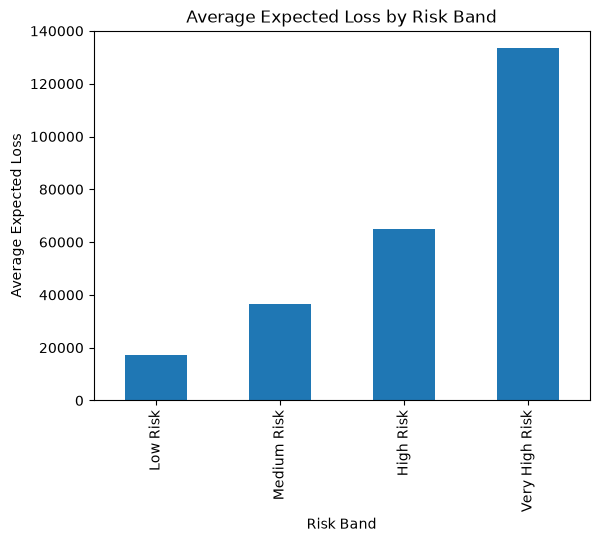

In [15]:
risk_band_el_summary["Average_Expected_Loss"].plot(kind="bar")

plt.title("Average Expected Loss by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Average Expected Loss")
plt.show()

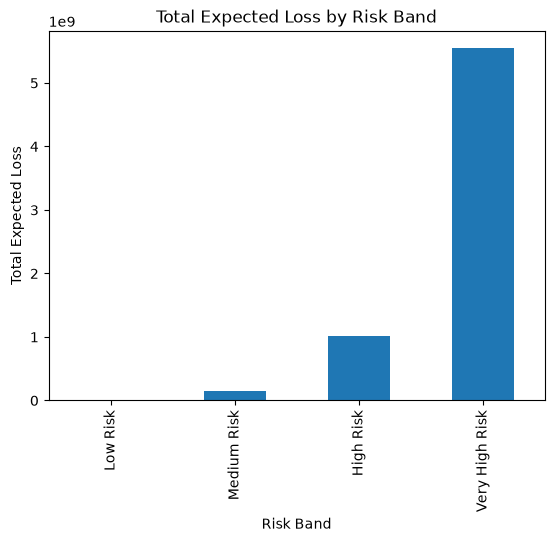

In [16]:
risk_band_el_summary["Total_Expected_Loss"].plot(kind="bar")

plt.title("Total Expected Loss by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Total Expected Loss")
plt.show()

In [17]:
el_df["Risk_Decile"] = pd.qcut(
    el_df["Probability_of_Default"],
    q=10,
    labels=False,
    duplicates="drop"
)

decile_el_summary = el_df.groupby("Risk_Decile").agg(
    Applicant_Count=("Expected_Loss", "count"),
    Average_PD=("Probability_of_Default", "mean"),
    Average_EAD=("EAD", "mean"),
    Average_Expected_Loss=("Expected_Loss", "mean"),
    Total_Expected_Loss=("Expected_Loss", "sum"),
    Actual_Default_Rate=("Actual_Default", "mean")
).sort_values("Average_PD", ascending=False)

decile_el_summary

,Applicant_Count,Average_PD,Average_EAD,Average_Expected_Loss,Total_Expected_Loss,Actual_Default_Rate
Risk_Decile,,,,,,
9,6151,0.792383,534414.814502,190391.401485,1.171098e+09,0.263209
8,6150,0.656966,543961.510244,160757.007750,9.886556e+08,0.145366
7,6150,0.566999,564898.424634,144125.844846,8.863739e+08,0.105691
6,6150,0.492372,580936.181707,128711.897658,7.915782e+08,0.080163
5,6150,0.426158,590853.632195,113315.940751,6.968930e+08,0.063902
4,6151,0.367458,595044.795968,98342.365184,6.049039e+08,0.045521
3,6150,0.313505,603273.441220,85104.662876,5.233937e+08,0.037561
2,6150,0.260542,616462.604634,72277.365378,4.445058e+08,0.031382
1,6150,0.204510,638865.376098,58752.093005,3.613254e+08,0.019024


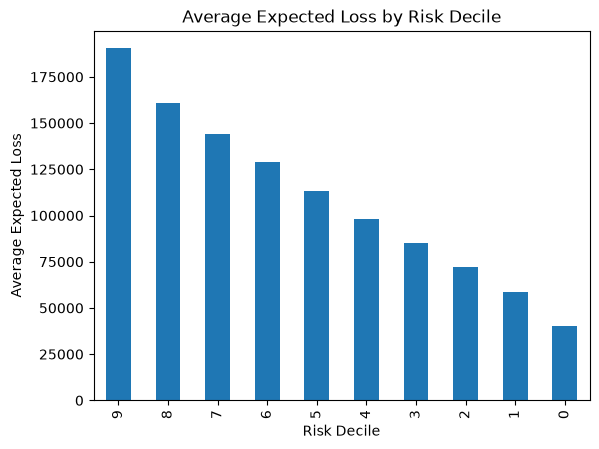

In [18]:
decile_el_summary["Average_Expected_Loss"].plot(kind="bar")

plt.title("Average Expected Loss by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Average Expected Loss")
plt.show()

In [19]:
el_df.to_csv("../data/processed/expected_loss_framework_output.csv", index=False)
risk_band_el_summary.to_csv("../data/processed/risk_band_expected_loss_summary.csv")
decile_el_summary.to_csv("../data/processed/decile_expected_loss_summary.csv")

## Expected Loss Business Interpretation

This notebook converts modelled Probability of Default into an Expected Loss framework.

Unlike the earlier notebooks that focused on default prediction, this notebook estimates the potential monetary loss associated with each applicant.

The Expected Loss formula combines:

- Probability of Default
- Loss Given Default
- Exposure at Default

Using `AMT_CREDIT` as EAD makes this expected loss framework more realistic than using a fixed exposure assumption.

The output can support:

1. Credit risk ranking
2. Portfolio loss estimation
3. Risk-based pricing
4. Provisioning analysis
5. Lending policy decisions

This completes the core Home Credit credit risk modelling workflow:

Data Understanding → EDA → Missing Value Analysis → Baseline PD Model → Feature Engineering → Model Validation → Expected Loss Framework